Bibliotheken importeren

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
import random
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import sqlite3

Data inlezen en kolommen selecteren

In [35]:
# from datetime import datetime
# database_conn = sqlite3.connect('Project/adventureworks.sqlite')
# df = pd.read_sql_query("select JobTitle, BirthDate, MaritalStatus, Gender, HireDate, SickLeaveHours from HumanResources_Employee", database_conn)

# df['BirthDate'] = pd.to_datetime(df['BirthDate']) 
# huidig_jaar = datetime.now().year
# df['Age'] = huidig_jaar - df['BirthDate'].dt.year

# df


In [36]:
from datetime import datetime

sales_conn = sqlite3.connect('go_sales_train.sqlite')

df_order = pd.read_sql_query("select QUANTITY, PRODUCT_NUMBER, UNIT_COST, UNIT_PRICE, UNIT_SALE_PRICE from order_details", sales_conn)
df_product = pd.read_sql_query("select PRODUCT_NUMBER, INTRODUCTION_DATE, PRODUCT_TYPE_CODE, PRODUCTION_COST, MARGIN from product", sales_conn)
# df_product_type = pd.read_sql_query("select PRODUCT_TYPE_CODE, PRODUCT_TYPE_EN from product_type", sales_conn)

df = pd.merge(df_order, df_product, on="PRODUCT_NUMBER", how="left")
# df = pd.merge(df, df_product_type, on="PRODUCT_TYPE_CODE", how="left")

df['INTRODUCTION_DATE'] = pd.to_datetime(df['INTRODUCTION_DATE'])
huidig_jaar = datetime.now().year
df['YearsSinceIntroduction'] = huidig_jaar - df['INTRODUCTION_DATE'].dt.year
df = df.drop(columns=['PRODUCT_NUMBER'])
df

,QUANTITY,UNIT_COST,UNIT_PRICE,UNIT_SALE_PRICE,INTRODUCTION_DATE,PRODUCT_TYPE_CODE,PRODUCTION_COST,MARGIN,YearsSinceIntroduction
0,84,4.38,6.59,6.59,1995-02-15,1,4.0,0.33,30
1,126,4.38,6.59,6.59,1995-02-15,1,4.0,0.33,30
2,122,4.38,6.59,6.03,1995-02-15,1,4.0,0.33,30
3,122,4.38,6.59,6.59,1995-02-15,1,4.0,0.33,30
4,272,4.38,6.59,5.26,1995-02-15,1,4.0,0.33,30
...,...,...,...,...,...,...,...,...,...
37752,70,6.00,9.00,9.00,2004-01-10,21,6.0,0.33,21
37753,44,6.00,12.00,9.00,2004-01-15,21,6.0,0.50,21
37754,8,80.00,200.00,140.00,2003-12-15,21,80.0,0.60,22
37755,24,5.00,10.00,10.00,2003-12-27,21,5.0,0.50,22


Onafhankelijke niet-numerieke variabelen

In [37]:
# dummies_dataframe = pd.get_dummies(df.loc[:, ['PRODUCT_TYPE_EN' ]])
# dummies_dataframe

Mergen en replacen

In [38]:
# df = pd.concat([df, dummies_dataframe], axis=1)
# df = df.drop(columns=['PRODUCT_TYPE_EN', 'INTRODUCTION_DATE'], axis=1)
# df

df = df.drop(columns=['INTRODUCTION_DATE'], axis=1)
df

,QUANTITY,UNIT_COST,UNIT_PRICE,UNIT_SALE_PRICE,PRODUCT_TYPE_CODE,PRODUCTION_COST,MARGIN,YearsSinceIntroduction
0,84,4.38,6.59,6.59,1,4.0,0.33,30
1,126,4.38,6.59,6.59,1,4.0,0.33,30
2,122,4.38,6.59,6.03,1,4.0,0.33,30
3,122,4.38,6.59,6.59,1,4.0,0.33,30
4,272,4.38,6.59,5.26,1,4.0,0.33,30
...,...,...,...,...,...,...,...,...
37752,70,6.00,9.00,9.00,21,6.0,0.33,21
37753,44,6.00,12.00,9.00,21,6.0,0.50,21
37754,8,80.00,200.00,140.00,21,80.0,0.60,22
37755,24,5.00,10.00,10.00,21,5.0,0.50,22


Snijden

In [39]:
X = df.loc[df['QUANTITY'].notna(), :]
X = X.drop('QUANTITY', axis = 1)
y = df.loc[df['QUANTITY'].notna(), ['QUANTITY']]
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37757 entries, 0 to 37756
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UNIT_COST               37757 non-null  float64
 1   UNIT_PRICE              37757 non-null  float64
 2   UNIT_SALE_PRICE         37757 non-null  float64
 3   PRODUCT_TYPE_CODE       37757 non-null  int64  
 4   PRODUCTION_COST         37757 non-null  float64
 5   MARGIN                  37757 non-null  float64
 6   YearsSinceIntroduction  37757 non-null  int32  
dtypes: float64(5), int32(1), int64(1)
memory usage: 2.2 MB


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.15,
    random_state = 42
)

In [41]:
reg_model = linear_model.LinearRegression()
reg_model = LinearRegression().fit(X_train, y_train)
reg_model

LinearRegression()

In [42]:
y_pred= reg_model.predict(X_test)
y_pred

array([[30.55019657],
       [47.98240565],
       [55.79556617],
       ...,
       [38.40826073],
       [44.40002876],
       [53.63103505]], shape=(5664, 1))

In [43]:
prediction_df = pd.DataFrame(y_pred)
prediction_df = prediction_df.rename(columns = {0 : 'Predicted_Qty'})
prediction_df

,Predicted_Qty
0,30.550197
1,47.982406
2,55.795566
3,79.856712
4,40.740976
...,...
5659,40.540658
5660,40.427467
5661,38.408261
5662,44.400029


In [44]:
prediction_df = pd.DataFrame(y_pred)
prediction_df = prediction_df.rename(columns = {0 : 'Predicted_Qty'})
prediction_df

,Predicted_Qty
0,30.550197
1,47.982406
2,55.795566
3,79.856712
4,40.740976
...,...
5659,40.540658
5660,40.427467
5661,38.408261
5662,44.400029


In [45]:
y_test_prediction_merge = pd.concat([y_test.reset_index()['QUANTITY'], prediction_df], axis = 1)
y_test_prediction_merge.loc[y_test_prediction_merge['Predicted_Qty'].notna(), :]

,QUANTITY,Predicted_Qty
0,298,30.550197
1,24,47.982406
2,28,55.795566
3,64,79.856712
4,192,40.740976
...,...,...
5659,36,40.540658
5660,26,40.427467
5661,16,38.408261
5662,18,44.400029


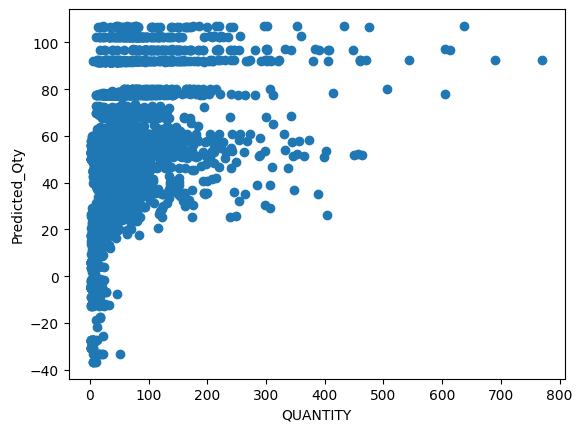

In [46]:
plt.scatter(y_test_prediction_merge['QUANTITY'], y_test_prediction_merge['Predicted_Qty'])
plt.xlabel('QUANTITY')
plt.ylabel('Predicted_Qty')
plt.show()

In [47]:
mean_squared_error(y_test_prediction_merge['QUANTITY'], y_test_prediction_merge['Predicted_Qty'])

2804.4485256940984

In [48]:
mean_absolute_error(y_test_prediction_merge['QUANTITY'], y_test_prediction_merge['Predicted_Qty'])

31.4840934974889